# Feature Engineering — Ventanas Temporales con DuckDB

**Objetivo:** Transformar logs de texto en features numéricas que capturen comportamiento anómalo.

**Estrategia:** Ventanas deslizantes retrospectivas (solo datos pasados, sin lookahead).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.data.loader import load_bgl_logs
from src.data.preprocessor import add_severity_score, train_test_split_temporal
from src.features.engineering import build_features, save_features

plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('../data/raw/BGL.log')
N_ROWS = 500_000

In [2]:
print('Cargando datos...')
df_raw = load_bgl_logs(DATA_PATH, nrows=N_ROWS)
df_raw = add_severity_score(df_raw)
print(f'Shape raw: {df_raw.shape}')
print(f'Anomalías: {df_raw["is_anomaly"].sum():,} ({df_raw["is_anomaly"].mean():.1%})')

Cargando datos...
Shape raw: (500000, 11)
Anomalías: 206,847 (41.4%)


## 1. Split temporal (sin data leakage)

In [3]:
df_train, df_test = train_test_split_temporal(df_raw, test_fraction=0.2)
print(f'Train: {len(df_train):,} eventos | {df_train["is_anomaly"].sum():,} anomalías')
print(f'Test:  {len(df_test):,} eventos  | {df_test["is_anomaly"].sum():,} anomalías')
print(f'Train hasta: {df_train["timestamp"].max()}')
print(f'Test desde:  {df_test["timestamp"].min()}')

Train: 400,000 eventos | 172,367 anomalías
Test:  100,000 eventos  | 34,480 anomalías
Train hasta: 2005-06-13 17:45:20.517798
Test desde:  2005-06-13 17:45:20.559003


## 2. Construcción de features

In [4]:
%%time
print('Construyendo features de training...')
df_feat_train, scaler = build_features(df_train, fit_scaler=True)
print(f'Shape features train: {df_feat_train.shape}')
print()
feature_cols = [c for c in df_feat_train.columns if c not in {'timestamp', 'node', 'is_anomaly'}]
print(f'Total features: {len(feature_cols)}')
print(feature_cols)

Construyendo features de training...
Shape features train: (400000, 33)

Total features: 30
['total_count_1min', 'error_count_1min', 'warning_count_1min', 'fatal_count_1min', 'avg_severity_1min', 'unique_nodes_1min', 'total_count_5min', 'error_count_5min', 'warning_count_5min', 'fatal_count_5min', 'avg_severity_5min', 'unique_nodes_5min', 'total_count_15min', 'error_count_15min', 'warning_count_15min', 'fatal_count_15min', 'avg_severity_15min', 'unique_nodes_15min', 'error_rate_5min', 'fatal_rate_5min', 'burst_flag', 'node_error_ratio', 'node_avg_severity', 'comp_kernel', 'comp_app', 'comp_discovery', 'comp_linkcard', 'comp_mmcs', 'comp_hardware', 'comp_cmcs']
CPU times: user 17.4 s, sys: 5.34 s, total: 22.8 s
Wall time: 4.84 s


In [5]:
df_feat_train[feature_cols].describe().round(3)

,total_count_1min,error_count_1min,warning_count_1min,fatal_count_1min,avg_severity_1min,unique_nodes_1min,total_count_5min,error_count_5min,warning_count_5min,fatal_count_5min,...,burst_flag,node_error_ratio,node_avg_severity,comp_kernel,comp_app,comp_discovery,comp_linkcard,comp_mmcs,comp_hardware,comp_cmcs
count,400000.000,400000.000,400000.000,400000.000,400000.000,400000.000,400000.000,400000.000,400000.000,400000.000,...,400000.000,400000.000,400000.000,400000.000,400000.000,400000.000,400000.000,400000.000,400000.000,400000.000
mean,0.347,0.553,0.002,0.553,0.431,0.366,0.286,0.512,0.004,0.512,...,-0.458,0.340,0.248,-0.015,0.014,0.000,0.000,0.000,0.000,0.000
std,0.538,0.989,0.128,0.989,0.493,0.525,2.099,0.842,0.244,0.842,...,0.498,0.469,0.473,0.121,0.119,0.017,0.015,0.005,0.004,0.003
min,-0.295,-0.045,0.000,-0.045,-0.012,-0.061,-2.260,-0.020,0.000,-0.020,...,-1.000,-0.091,-0.200,-1.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.018,-0.045,0.000,-0.045,-0.012,-0.061,-0.773,-0.020,0.000,-0.020,...,-1.000,-0.091,-0.200,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.982,0.955,0.000,0.955,0.988,0.939,0.227,0.980,0.000,0.980,...,0.000,0.909,0.800,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,1.649,5.037,14.000,5.037,0.988,1.503,8.826,4.860,29.000,4.860,...,0.000,0.909,0.800,0.000,1.000,1.000,1.000,1.000,1.000,1.000


## 3. Análisis de features — separabilidad anomalía vs normal

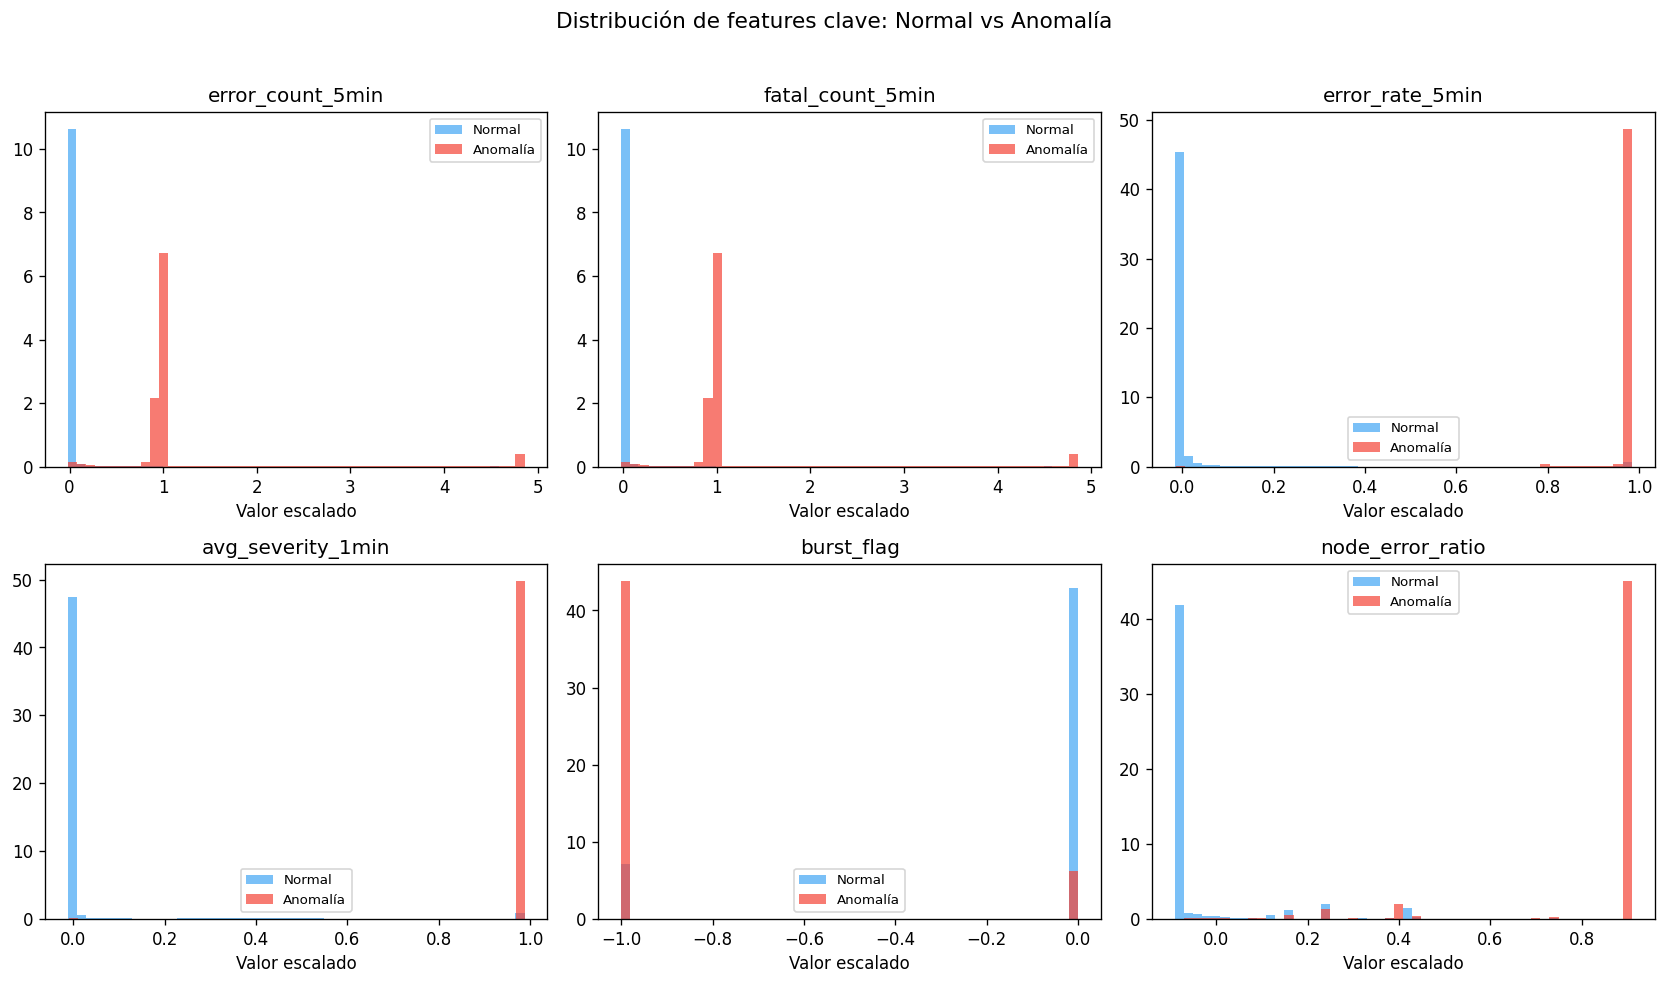

In [6]:
key_features = ['error_count_5min', 'fatal_count_5min', 'error_rate_5min', 
                'avg_severity_1min', 'burst_flag', 'node_error_ratio']
key_features = [f for f in key_features if f in df_feat_train.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    normal = df_feat_train[~df_feat_train['is_anomaly']][feat].dropna()
    anomaly = df_feat_train[df_feat_train['is_anomaly']][feat].dropna()
    
    ax.hist(normal, bins=50, alpha=0.6, color='#2196F3', label='Normal', density=True)
    ax.hist(anomaly, bins=50, alpha=0.7, color='#F44336', label='Anomalía', density=True)
    ax.set_title(feat)
    ax.set_xlabel('Valor escalado')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de features clave: Normal vs Anomalía', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlación entre features

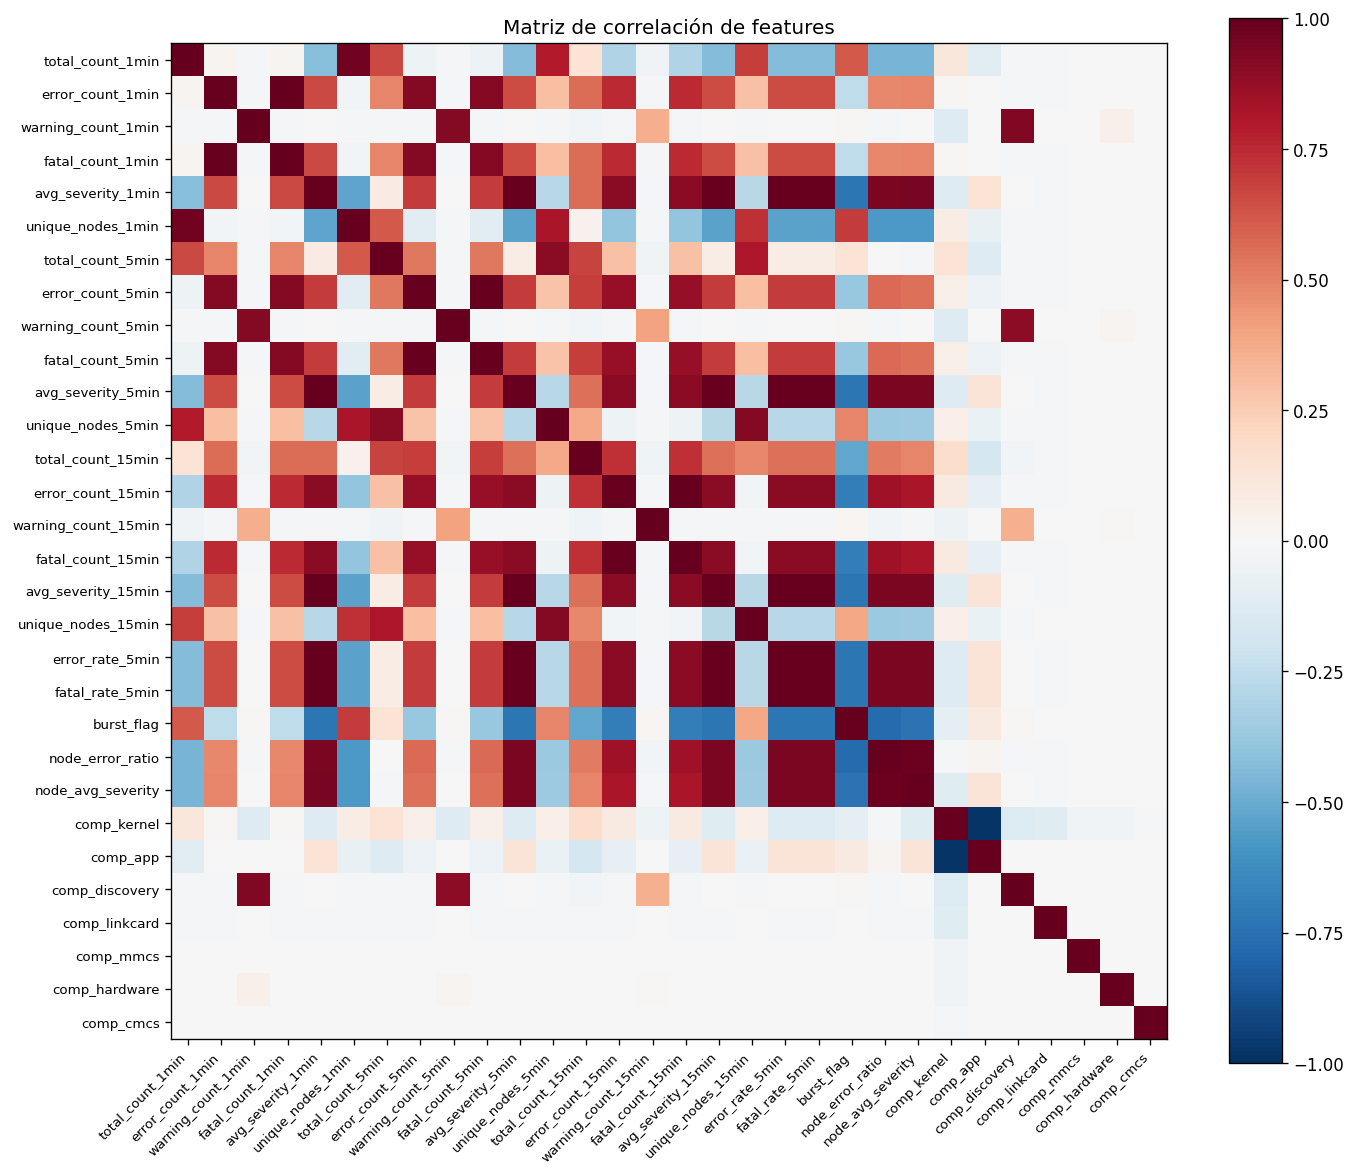

In [7]:
corr = df_feat_train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title('Matriz de correlación de features')
plt.tight_layout()
plt.savefig('../reports/figures/02_correlation_matrix.png', dpi=150)
plt.show()

## 5. Guardar features procesadas

In [8]:
save_features(df_feat_train, '../data/processed/features_train.parquet')
print(f'Features guardadas: data/processed/features_train.parquet')
print(f'Shape: {df_feat_train.shape}')

Features guardadas: data/processed/features_train.parquet
Shape: (400000, 33)


## Conclusiones

- `error_rate_5min` y `fatal_count_5min` muestran la mejor separabilidad entre clases
- `burst_flag` captura spikes de eventos que correlacionan con anomalías
- `node_error_ratio` añade contexto histórico del nodo — diferencia nodos problemáticos de nodos estables
- Las features de ventana 5min son las más informativas (balance entre granularidad y estabilidad estadística)
- Sin data leakage: todas las ventanas calculadas solo con datos anteriores al evento actual